# Super Jupiter evolution tutorial

This tutorial shows the evolution of super-Jupiter (> 1 M$_J$) planetary structures under homogeneous conditions (for now). The example .ini files in [`parameter_examples/`](../parameter_examples/) named `parameter_user_<N>mj.ini` set the planet mass via `M_MJup = <N>.0`, which scales the mass relative to 1 M$_J$. So the difference between [`parameter_user.ini`](../parameter_examples/parameter_user.ini) and [`parameter_user_8mj.ini`](../parameter_examples/parameter_user_8mj.ini) is essentially `M_MJup = 1.0` → `M_MJup = 8.0`.

**Before running:** make sure the EOS submodule is initialized (`git submodule update --init --recursive`) and you're in the `orchard_env` conda environment. The notebooks `os.chdir(..)` to the repo root in the first cell.

**Runtime:** each homogeneous super-Jupiter model runs in a few minutes on a personal computer. The full M-R relation below loads pre-computed results from `models/`. To reproduce them from scratch, run e.g. `python evolution.py --config parameter_examples/parameter_user_8mj.ini` for each .ini.

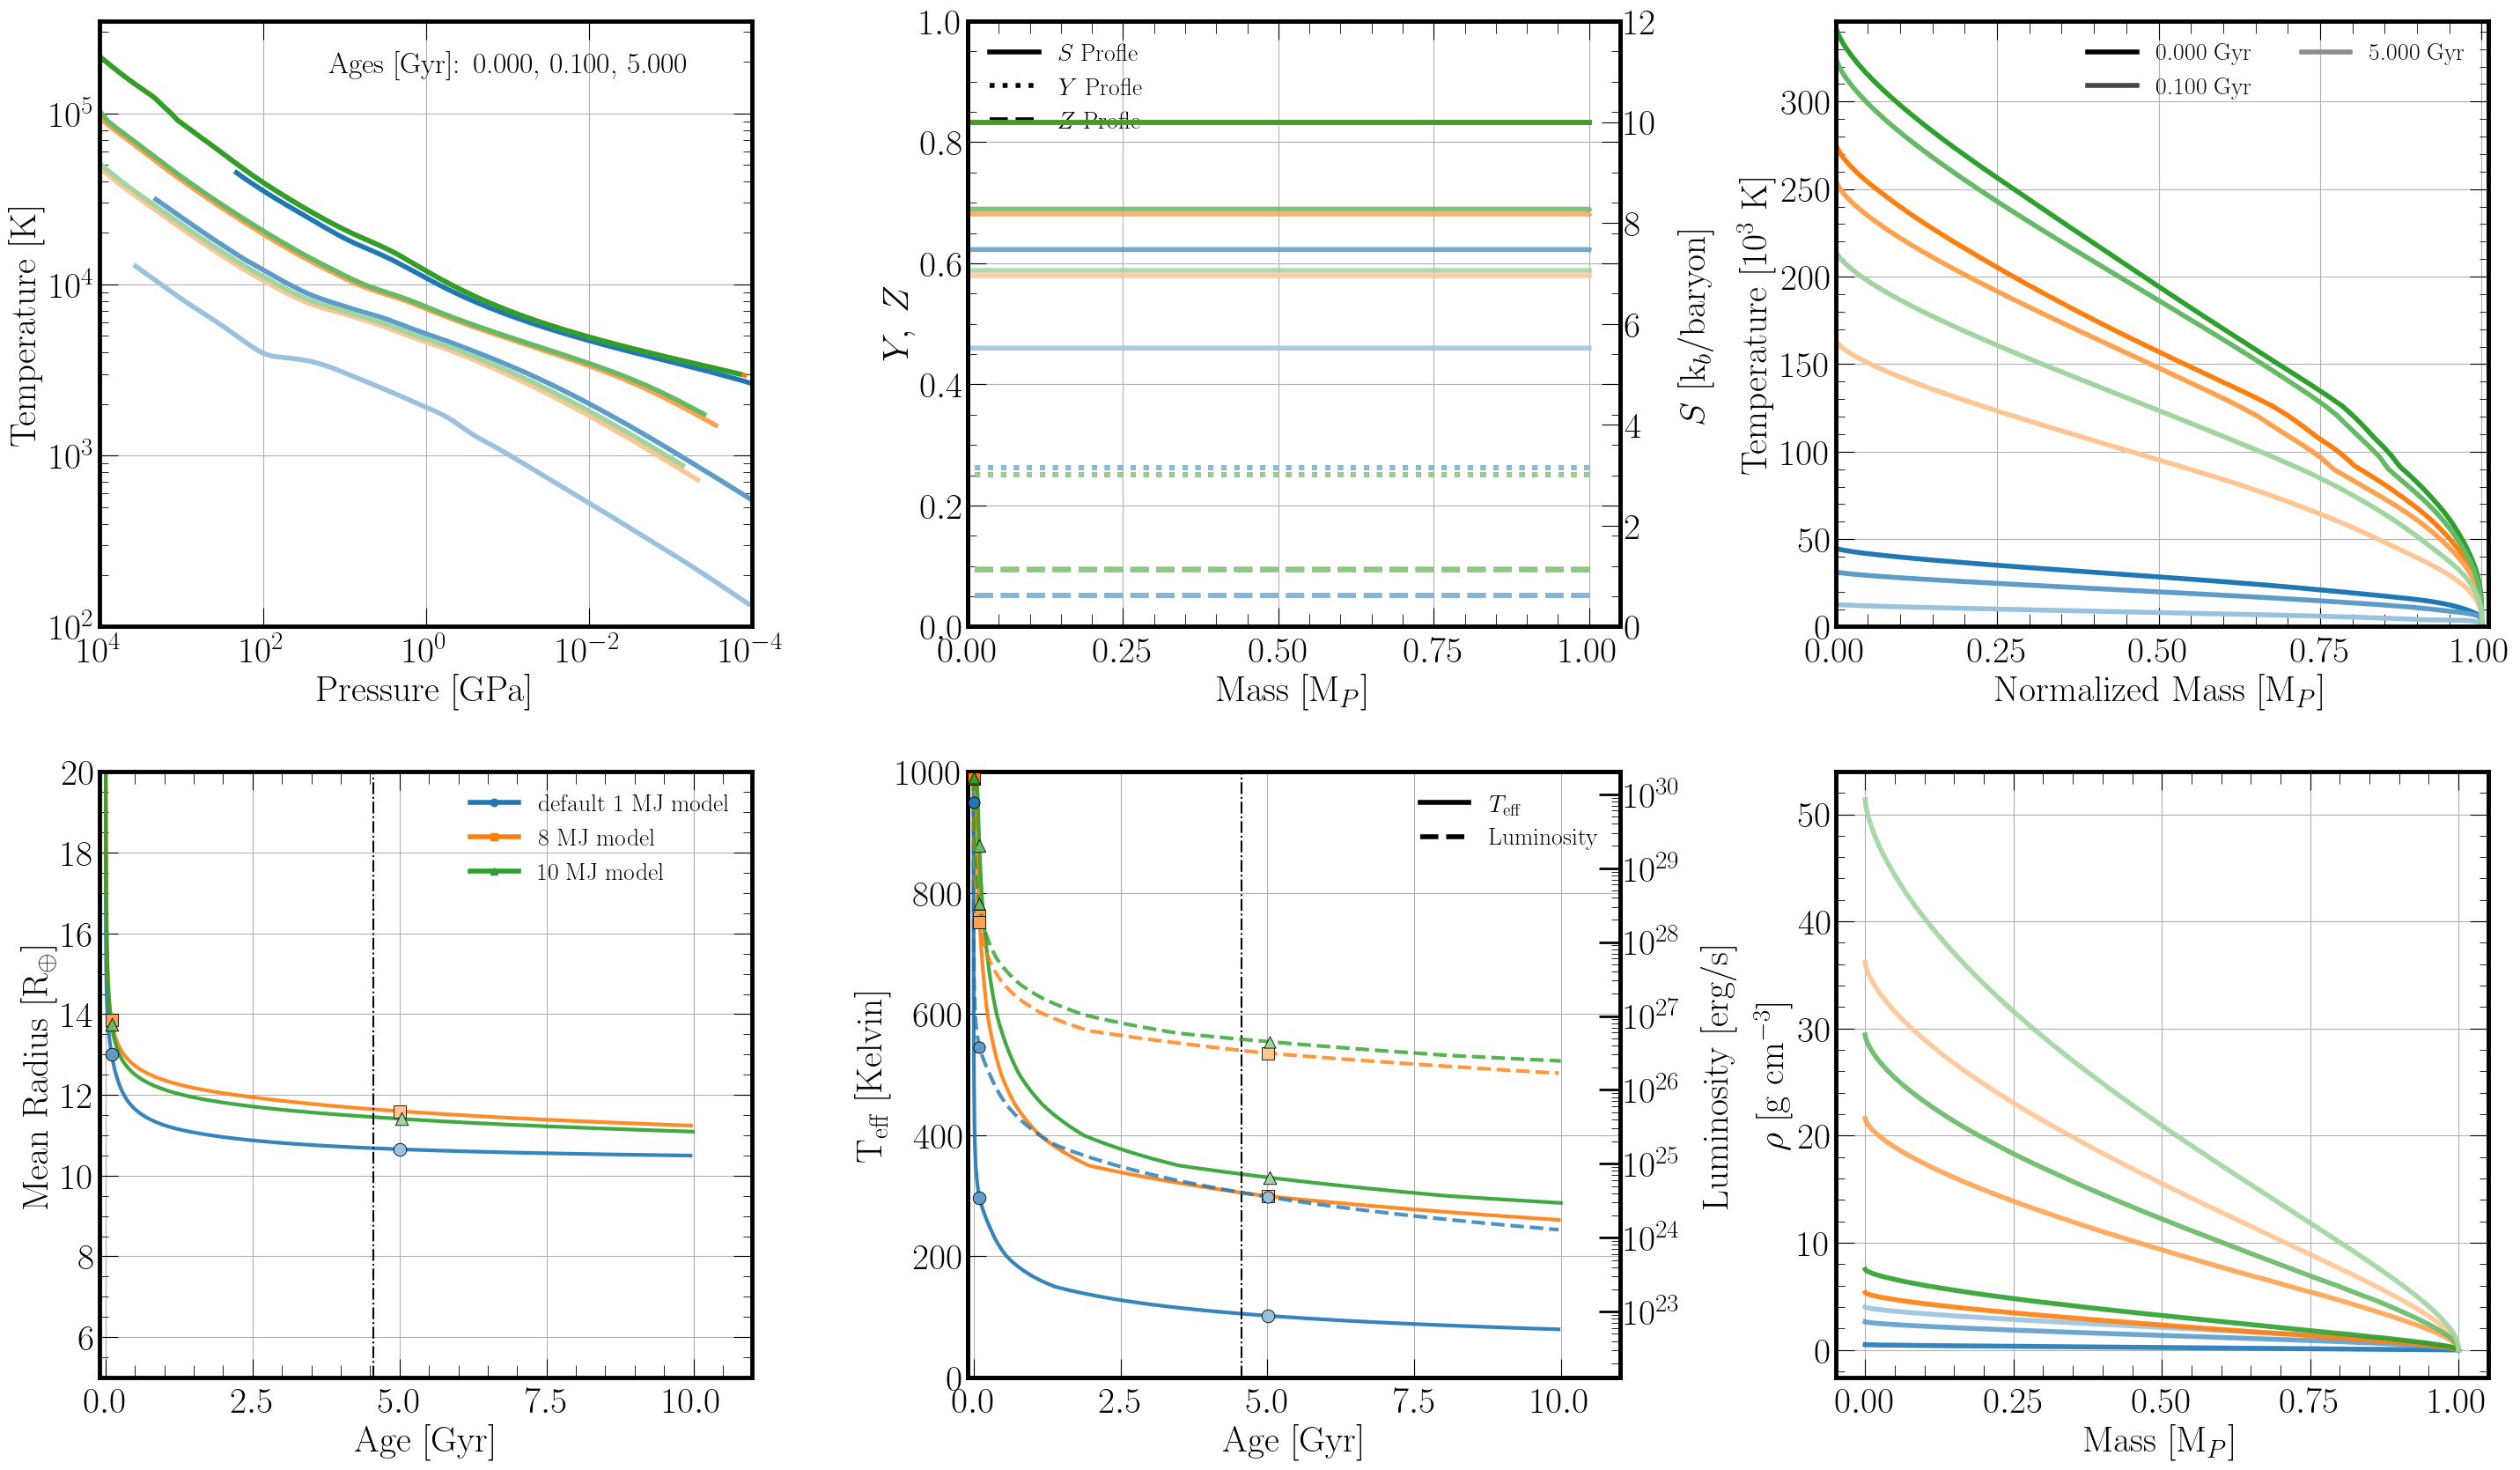

In [1]:
import plot_class

paths = [
    "parameter_examples/parameter_user.ini",
    "parameter_examples/parameter_user_8mj.ini",
    "parameter_examples/parameter_user_10mj.ini"
]


init = plot_class.init_plot(paths = paths)

labels = [
    r'default 1 MJ model',
    r'8 MJ model',
    r'10 MJ model'
]


init.age_plot(
    ages=[0.0, 0.1, 5.0],
    output_file='age_compare',
    labels=labels,
    save=False, # option to save the plot in the plots/ folder
    leg_size=20,
)


**WARNING**: If you set a compact core to these super-Jupiter models, the core EOS may not encompass the pressures and temperatures demanded of it, so the code might fail. I recommend not incorporating compact cores in super-Jupiter models since compact cores are likely less influential in these mass regimes.

**NOTE**: All of these example models use `Z_ini = 0.017`, which is roughly 1× solar with $Z_\odot = 0.017$ (Chen et al. 2023). The total metal mass therefore scales with the planet's total mass. This is for demonstration purposes only.

**NOTE**: All the models in this tutorial are isolated (no irradiation), because the `c26` boundary condition tables are built for isolated super-Jupiters. If you want a strongly irradiated giant, use the `c23` tables with `irradiation = True` and an appropriate `t_eq` (see the Jupiter examples in `tutorial_solarsystem_planets.ipynb`). Keep in mind that reproducing the most inflated hot Jupiters requires additional heating mechanisms that we do not model here. That exploration is left as an exercise to the reader.

## Homogeneous/adiabatic M-R relation for Jupiter-sized planets

Let's compute an additional 0.1, 0.3 (Saturn-ish mass), 2, 3 and 5 Jupiter mass evolution models and build an M-R relation. All of these models share the same composition and are isolated, so this is a fixed-composition cooling M-R relation, not a population prediction. Above roughly 13 M$_J$ deuterium burning becomes relevant, and `ORCHARD` does not model it, so treat everything here as planetary structures only.

In [2]:
import load_models
from utils import const

paths = [
    "parameter_examples/parameter_user_0.1mj.ini",
    "parameter_examples/parameter_user_0.3mj.ini",
    "parameter_examples/parameter_user.ini",
    "parameter_examples/parameter_user_2mj.ini",
    "parameter_examples/parameter_user_3mj.ini",
    "parameter_examples/parameter_user_5mj.ini",
    "parameter_examples/parameter_user_8mj.ini",
    "parameter_examples/parameter_user_10mj.ini",

]

models = load_models.load(paths)

Reading files...
Finished reading files...


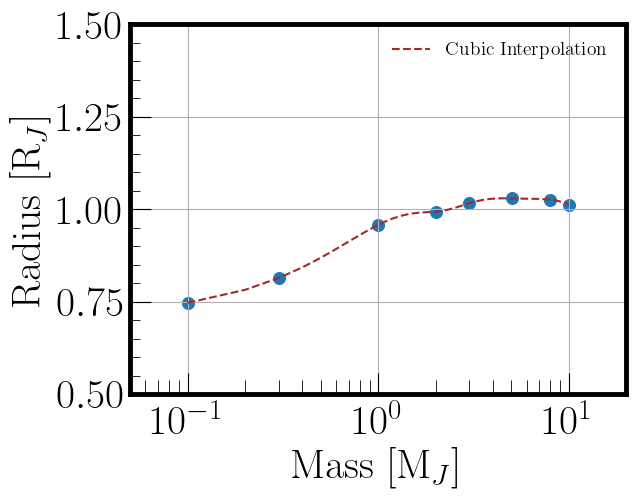

In [3]:
radius_final = [models[i]['data_rad'][-1]/const.rjup for i in range(len(paths))]
masses = [models[i]['mass_grid'][0]/const.mjup for i in range(len(paths))]

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

r_M = interp1d(masses, radius_final, kind='cubic', fill_value='extrapolate') # simple cubic interpolation for demonstration purposes only

masses_interp = np.linspace(0.1, 10.0, 100)
radius_interp = r_M(masses_interp)


plt.scatter(masses, radius_final, s=70)
plt.plot(masses_interp, radius_interp, label='Cubic Interpolation', color='brown', ls='--')
plt.xscale('log')
plt.xlabel(r'Mass [M$_J$]')
plt.ylabel(r'Radius [R$_J$]')
plt.minorticks_on()
plt.ylim(0.5, 1.5)
plt.xlim(0.05, 20)
plt.legend(frameon=False, fontsize=14)
plt.show()

This is only an exercise. In reality, the observed M-R relation yields smaller radii above about a Saturn mass; see Chen & Kipping (2017, *ApJ* 834, 17) and Müller et al. (2024) for empirical fits. The smooth cubic interpolation above (drawn through 8 model points) is a visualization only; treat it as a sketch of the trend rather than a quantitative prediction. Real Jupiter-class exoplanets also span a wide range of insolation, age, and helium/metal fractionation, all of which affect the observed radius.